In [2]:
import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import mnist
from scipy.special import softmax

Loads the MNIST dataset.  This is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images. More info can be found at the [MNIST homepage](http://yann.lecun.com/exdb/mnist/).

Args: path: path where to cache the dataset locally (relative to `~/.keras/datasets`).

Returns: Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

**`x_train`**: `uint8` NumPy array of grayscale image data with shapes `(60000, 28, 28)`, containing the training data. Pixel values range from 0 to 255.

**`y_train`**: `uint8` NumPy array of digit labels (integers in range 0-9) with shape `(60000,)` for the training data.

**`x_test`**: `uint8` NumPy array of grayscale image data with shapes `(10000, 28, 28)`, containing the test data. Pixel values range from 0 to 255.

**`y_test`**: `uint8` NumPy array of digit labels (integers in range 0-9) with shape `(10000,)` for the test data.  

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

Label: 5


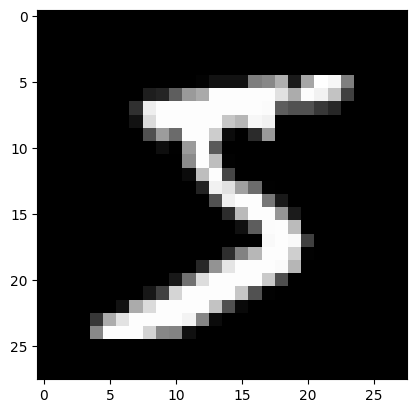

In [5]:
# Print label and show image
print("Label:", y_train[0])
plt.imshow(x_train[0], cmap="gray")
plt.show()

In [6]:
input_size = x_train.shape[1] * x_train.shape[2]
print(input_size)

784


In [7]:
# Flatten: reshape each 28x28 image into a 784 vector
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print("Flattened shape (train):", x_train.shape)
print("Flattened shape (test):", x_test.shape)

Flattened shape (train): (60000, 784)
Flattened shape (test): (10000, 784)


In [8]:
 # def softmax(self, input):
    #     exp_list = np.array([np.exp(i) for i in input])
    #     sum_exp_list = sum(exp_list)
    #     return exp_list / sum_exp_list

Define $x$ as an input column vector of size $n_0$

Model Params:
$L$ - number of layers
For $i = 1, \ldots, L$:
$n_i$ - number of neurons in i-th layer
$$w^{(i)} =
\begin{bmatrix}
w_{11} & \cdots & w_{1n_{i-1}} \\
\vdots & \ddots & \vdots \\
w_{n_{i}1} & \cdots & w_{n_{i}n_{i-1}}
\end{bmatrix}$$





In [9]:
class NeuralNetwork():
    def __init__(self, layer_sizes, input = False):
        self.layer_sizes = layer_sizes
        self.biases = [np.random.randn(layer) for layer in layer_sizes[1:]]
        self.weights = [np.random.randn(layer_sizes[i + 1], layer_sizes[i])
                        for i in range(len(layer_sizes) - 1)]
       
    def activation_output(self, input, layer, activation_function):
        activation_function(np.dot(self.weights[layer], input) + self.biases)
        
    def activation(self, input):
        return softmax(self.weighted_input(input))

In [10]:
NN = NeuralNetwork(layer_sizes=[input_size, 2])

In [11]:
NN.biases
# print(NN.weighted_input(x_train[0]))
# print((NN.activation(x_train[0])))

[array([-0.21852312,  0.4542352 ])]

In [12]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

def derivative_logistic(x):
    return logistic(x) * (1 - logistic(x))


In [13]:
NN.weights

[array([[ 0.77356781,  0.45484147,  0.79347513, ...,  0.69349388,
         -1.39776062,  1.33828115],
        [ 1.86741949, -1.6993183 ,  0.54882657, ...,  1.06085317,
         -0.46968186, -1.13643851]], shape=(2, 784))]